1. Import Libraries

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,precision_score,recall_score,f1_score,
    classification_report,confusion_matrix,ConfusionMatrixDisplay
)

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

2. Load the Dataset

In [2]:
df = pd.read_csv("nlp_dataset.csv")

In [3]:
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Dataset shape: (5937, 2)
Columns: ['Comment', 'Emotion']


,Comment,Emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear


3. Data Inspection

Before preprocessing, check for missing values and the distribution of emotion classes. A reasonably balanced target distribution helps avoid strong class imbalance effects.

In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Comment    0
Emotion    0
dtype: int64


In [6]:
print("\n Emotion distribution:")
print(df["Emotion"].value_counts())


 Emotion distribution:
Emotion
anger    2000
joy      2000
fear     1937
Name: count, dtype: int64


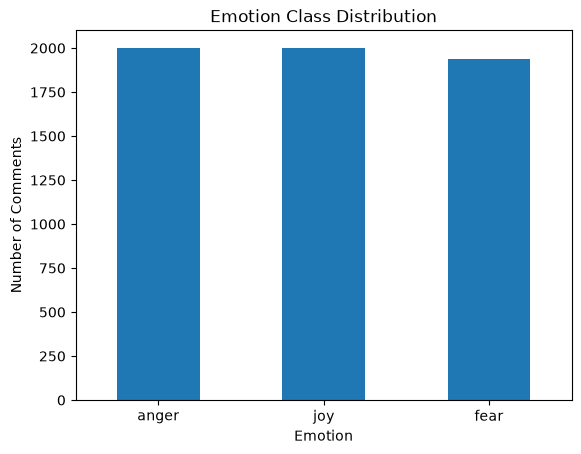

In [7]:
df["Emotion"].value_counts().plot(kind="bar",title= "Emotion Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.show()


4. Text Preprocessing

The following preprocessing steps are used:

1. **Missing-value removal** – rows without text or an emotion label are removed.
2. **Lowercasing** – converts `Happy` and `happy` into the same representation.
3. **URL/HTML removal** – removes web links and HTML tags that usually do not help emotion prediction.
4. **Punctuation and digit removal** – keeps alphabetic words and reduces unnecessary vocabulary.
5. **Whitespace normalization** – removes extra spaces.
6. **Tokenization** – the cleaned sentence is split into individual words.
7. **Stopword removal** – common English words such as the, is, and and are removed.

These steps reduce noise and vocabulary size. However, stopword removal can sometimes remove words that provide context, so it should be treated as a modelling choice rather than a universal rule.

In [8]:
df = df.dropna(subset=["Comment","Emotion"]).copy()
df["Comment"]= df["Comment"].astype(str)
df["Emotion"]= df["Emotion"].astype(str).str.strip()

stop_words = set(ENGLISH_STOP_WORDS)

In [9]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)  # URLs
    text = re.sub(r"<.*?>", " ", text)                # HTML tags
    text = re.sub(r"[^a-z\s]", " ", text)            # punctuation/digits
    text = re.sub(r"\s+", " ", text).strip()

    tokens =text.split()
    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

df["Clean_Comment"]= df["Comment"].apply(preprocess_text)
display(df[["Comment","Emotion","Clean_Comment"]].head())

    

,Comment,Emotion,Clean_Comment
0,i seriously hate one subject to death but now ...,fear,seriously hate subject death feel reluctant drop
1,im so full of life i feel appalled,anger,im life feel appalled
2,i sit here to write i start to dig out my feel...,fear,sit write start dig feelings think afraid acce...
3,ive been really angry with r and i feel like a...,joy,ive really angry r feel like idiot trusting place
4,i feel suspicious if there is no one outside l...,fear,feel suspicious outside like rapture happened


Why preprocessing helps
Raw text contains many variations and irrelevant characters. Cleaning and normalizing the text gives the vectorizer a more consistent vocabulary. Stopword removal can reduce the number of features and memory usage. The main risk is that some common words may carry useful linguistic context, so model performance should ultimately be checked on validation/test data.

5. Train-Test Split

In [10]:
X=df["Clean_Comment"]
y=df["Emotion"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [11]:
print("Training Samples:",len(X_train))
print("Test Samples:",len(X_test))

Training Samples: 4749
Test Samples: 1188


6. Feature Extraction using TF-IDF

Machine learning algorithms cannot directly process text. TF-IDF (Term Frequency-Inverse Document Frequency) converts each document into a numerical vector.

TF measures how frequently a word occurs in a document.
IDF gives lower weight to words that occur in many documents.
The resulting TF-IDF value represents how informative a word is for a particular document.
We use unigrams and bigrams (ngram_range=(1, 2)) so the model can learn both individual words and short phrases.

TfidfVectorizer also performs tokenization during vectorization; the explicit split() tokenization above is included to satisfy the preprocessing requirement and to demonstrate the process.

In [16]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (4749, 5101)
Testing shape: (1188, 5101)


7. Model Buliding

Multinomial Naive Bayes

In [18]:
nb_model = MultinomialNB(alpha=0.1)

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes Classification Report")
print(classification_report(y_test, nb_pred))

Naive Bayes Classification Report
              precision    recall  f1-score   support

       anger       0.89      0.90      0.89       400
        fear       0.87      0.90      0.89       388
         joy       0.93      0.89      0.91       400

    accuracy                           0.89      1188
   macro avg       0.90      0.89      0.89      1188
weighted avg       0.90      0.89      0.89      1188



Support Vector Machine

In [19]:
svm_model = LinearSVC(C=1.5, random_state=42)

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print("SVM Classification Report")
print(classification_report(y_test, svm_pred))

SVM Classification Report
              precision    recall  f1-score   support

       anger       0.94      0.93      0.93       400
        fear       0.94      0.94      0.94       388
         joy       0.95      0.95      0.95       400

    accuracy                           0.94      1188
   macro avg       0.94      0.94      0.94      1188
weighted avg       0.94      0.94      0.94      1188



8. Model Comparison

In [20]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Support Vector Machine"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Precision (weighted)": [
        precision_score(y_test, nb_pred, average="weighted"),
        precision_score(y_test, svm_pred, average="weighted")
    ],
    "Recall (weighted)": [
        recall_score(y_test, nb_pred, average="weighted"),
        recall_score(y_test, svm_pred, average="weighted")
    ],
    "F1-score (weighted)": [
        f1_score(y_test, nb_pred, average="weighted"),
        f1_score(y_test, svm_pred, average="weighted")
    ]
})

results.round(4)

,Model,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted)
0,Naive Bayes,0.8948,0.8957,0.8948,0.8949
1,Support Vector Machine,0.9411,0.9411,0.9411,0.9410


9. Confusion Matrices

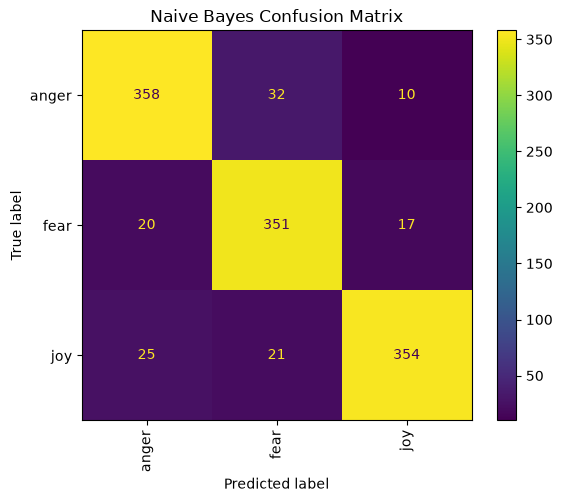

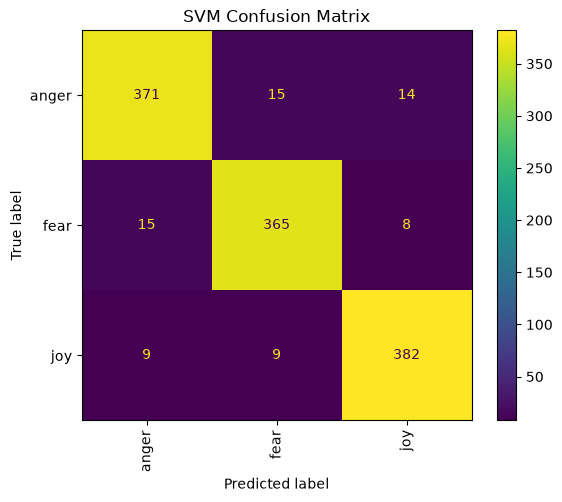

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, nb_pred,
    cmap=None,
    ax=ax,
    xticks_rotation="vertical"
)
ax.set_title("Naive Bayes Confusion Matrix")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, svm_pred,
    cmap=None,
    ax=ax,
    xticks_rotation="vertical"
)
ax.set_title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()

10. Predict Emotion for New Text

In [23]:
def predict_emotion(text):
    cleaned = preprocess_text(text)
    features = tfidf.transform([cleaned])
    return svm_model.predict(features)[0]

examples = [
    "I am so happy and excited for the day",
    "I am scared and worried about what will happen",
    "I am very angry about yesterday's incident"
]

for text in examples:
    print(f"Text: {text}")
    print(f"Predicted emotion: {predict_emotion(text)}")
    print()

Text: I am so happy and excited for the day
Predicted emotion: joy

Text: I am scared and worried about what will happen
Predicted emotion: fear

Text: I am very angry about yesterday's incident
Predicted emotion: anger



11. Final Conclusion 

For this dataset, Linear SVM is expected to be the stronger model because TF-IDF creates a high-dimensional sparse feature space, which is a setting where linear SVMs often perform very well.

Naive Bayes is valuable as a fast and interpretable baseline, while SVM generally provides stronger class-separation capability.

Expected result from the supplied dataset with the settings in this notebook:

Naive Bayes: approximately 89.5% accuracy / weighted F1
Linear SVM: approximately 94.1% accuracy / weighted F1
The exact values can vary slightly if the preprocessing, library versions, random seed or train/test split is changed.

Suitable model
Support Vector Machine (LinearSVC) is the recommended model for this assignment because it achieved the better test performance and is well suited to sparse TF-IDF text features.